# NYC Yellow Taxi - Analytical Results

Results from the supplied July 2026 file, built with dbt and DuckDB for the DSCOVR challenge.
Run `dbt build` before this notebook. Select the project `.venv` interpreter and run all cells in order.
The notebook reads the materialized marts; it does not redefine their aggregations or data-quality rules.


In [3]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.ticker import FuncFormatter

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

db_path = project_root / "data" / "db" / "yellow_tripdata.duckdb"
if not db_path.is_file():
    raise FileNotFoundError(f"Database not found: {db_path}. Run dbt build first.")

output_dir = project_root / "docs" / "images"
output_dir.mkdir(parents=True, exist_ok=True)

con = duckdb.connect(str(db_path), read_only=True)
print(f"DuckDB version: {duckdb.__version__}")

DuckDB version: 1.5.6


## A. Trips by time of day

Each accepted trip is assigned to the slot of its pickup timestamp. The panels show trip counts and revenue from the same accepted population.


In [4]:
time_of_day = con.sql("""
    select time_of_day, total_trips, total_revenue
    from mart_trips_by_time_of_day
    order by case time_of_day
        when 'morning' then 1
        when 'afternoon' then 2
        when 'evening' then 3
        when 'night' then 4
    end
""").df()

display(time_of_day)

,time_of_day,total_trips,total_revenue
0,morning,783098,22975159.42
1,afternoon,973005,30146663.99
2,evening,1096021,32945496.90
3,night,662677,20427685.44


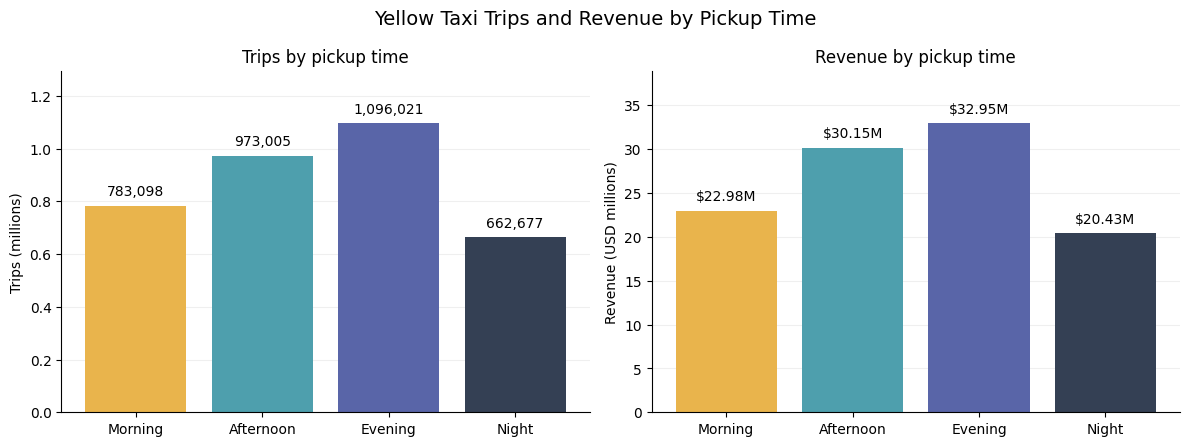

In [7]:
time_labels = time_of_day["time_of_day"].str.title()
time_colors = ["#E9B44C", "#4E9FAD", "#5965A8", "#344054"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].bar(time_labels, time_of_day["total_trips"], color=time_colors)
axes[0].set_title("Trips by pickup time")
axes[0].set_ylabel("Trips (millions)")
axes[0].yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value / 1_000_000:.1f}")
)
axes[0].bar_label(
    axes[0].containers[0],
    labels=[f"{value:,.0f}" for value in time_of_day["total_trips"]],
    padding=5,
    fontsize=10,
)

axes[1].bar(time_labels, time_of_day["total_revenue"], color=time_colors)
axes[1].set_title("Revenue by pickup time")
axes[1].set_ylabel("Revenue (USD millions)")
axes[1].yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value / 1_000_000:.0f}")
)
axes[1].bar_label(
    axes[1].containers[0],
    labels=[f"${value / 1_000_000:.2f}M" for value in time_of_day["total_revenue"]],
    padding=5,
    fontsize=10,
)

for ax in axes:
    ax.set_axisbelow(True)
    ax.grid(axis="y", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)
    ax.margins(y=0.18)

fig.suptitle("Yellow Taxi Trips and Revenue by Pickup Time", fontsize=14)

fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(
    output_dir / "trips_and_revenue_by_time_of_day.png", dpi=180, bbox_inches="tight"
)
plt.show()
plt.close(fig)

## B. Independent top-five pickup-zone rankings

The left panel selects `trip_count_rank <= 5`; the right selects `revenue_rank <= 5`.
Each list is ordered by its own rank. A zone may appear in both lists, and uses the same color in each panel.


In [8]:
top_trip_zones = con.sql("""
    select pickup_location_id, total_trips, total_revenue, trip_count_rank
    from mart_top_pickup_zones
    where trip_count_rank <= 5
    order by trip_count_rank
""").df()

top_revenue_zones = con.sql("""
    select pickup_location_id, total_trips, total_revenue, revenue_rank
    from mart_top_pickup_zones
    where revenue_rank <= 5
    order by revenue_rank
""").df()

display(top_trip_zones)
display(top_revenue_zones)

,pickup_location_id,total_trips,total_revenue,trip_count_rank
0,161,152110,4134513.26,1
1,132,149885,11765666.40,2
2,237,139876,3073613.81,3
3,236,118129,2690448.68,4
4,186,117287,3181219.43,5


,pickup_location_id,total_trips,total_revenue,revenue_rank
0,132,149885,11765666.40,1
1,138,88136,6141590.59,2
2,161,152110,4134513.26,3
3,230,108108,3332712.28,4
4,186,117287,3181219.43,5


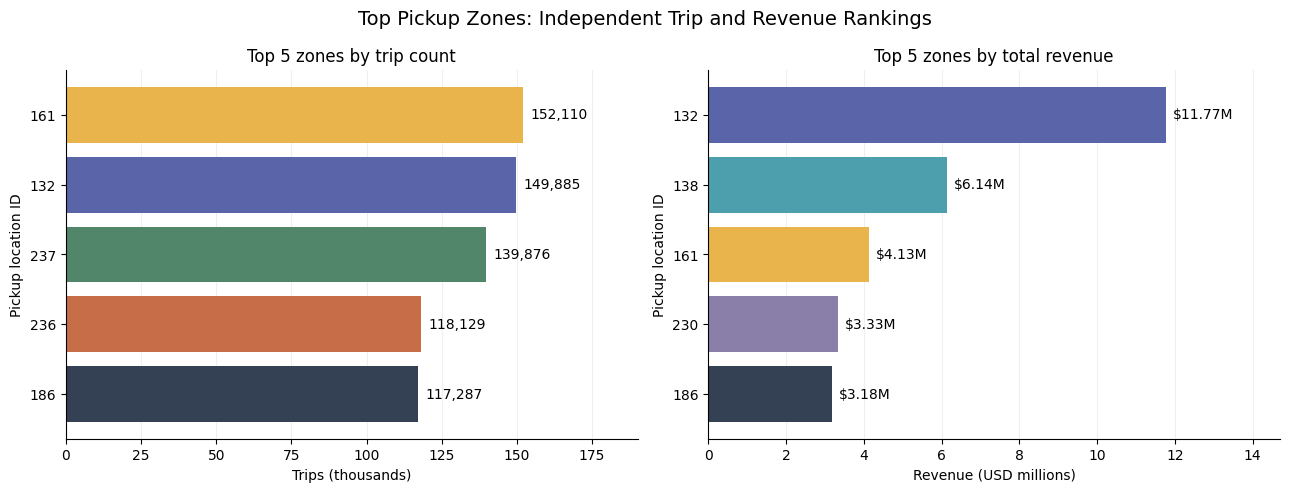

In [9]:
trip_zone_labels = top_trip_zones["pickup_location_id"].astype(str)
revenue_zone_labels = top_revenue_zones["pickup_location_id"].astype(str)
zone_ids = sorted(set(trip_zone_labels) | set(revenue_zone_labels))
zone_palette = [
    "#5965A8",
    "#4E9FAD",
    "#E9B44C",
    "#344054",
    "#8A7FA8",
    "#C76E49",
    "#51866B",
    "#946B87",
    "#607B8B",
    "#AA8F4C",
]
zone_colors = {zone_id: zone_palette[index] for index, zone_id in enumerate(zone_ids)}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.3))
axes[0].barh(
    trip_zone_labels,
    top_trip_zones["total_trips"],
    color=[zone_colors[zone_id] for zone_id in trip_zone_labels],
)
axes[0].set_title("Top 5 zones by trip count")
axes[0].set_xlabel("Trips (thousands)")
axes[0].set_ylabel("Pickup location ID")
axes[0].xaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value / 1_000:.0f}")
)
axes[0].bar_label(
    axes[0].containers[0],
    labels=[f"{value:,.0f}" for value in top_trip_zones["total_trips"]],
    padding=5,
)

axes[1].barh(
    revenue_zone_labels,
    top_revenue_zones["total_revenue"],
    color=[zone_colors[zone_id] for zone_id in revenue_zone_labels],
)
axes[1].set_title("Top 5 zones by total revenue")
axes[1].set_xlabel("Revenue (USD millions)")
axes[1].set_ylabel("Pickup location ID")
axes[1].xaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value / 1_000_000:.0f}")
)
axes[1].bar_label(
    axes[1].containers[0],
    labels=[
        f"${value / 1_000_000:.2f}M" for value in top_revenue_zones["total_revenue"]
    ],
    padding=5,
)

for ax in axes:
    ax.invert_yaxis()
    ax.margins(x=0.25)
    ax.set_axisbelow(True)
    ax.grid(axis="x", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Top Pickup Zones: Independent Trip and Revenue Rankings", fontsize=14)

fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(output_dir / "top_pickup_zones.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

## C. Vendor tip percentage

The metric is the mean of each trip's `tip_amount / total_amount`, expressed as a percentage.
`vendor_id` identifies a provider, not an individual driver.


In [10]:
vendor_performance = con.sql("""
    select vendor_id, avg_tip_percentage
    from mart_vendor_rate_performance
    order by vendor_id
""").df()

display(vendor_performance)

,vendor_id,avg_tip_percentage
0,1,10.61
1,2,8.78
2,6,0.00
3,7,13.27


## D. Distance analysis

The category boundaries are short `[0, 2)`, medium `[2, 5]`, and long `> 5` miles.
The mart includes all accepted records, including zero-duration trips. Negative-duration records are rejected by the central quality macro.


In [11]:
distance_analysis = con.sql("""
    select distance_category, total_trips, avg_trip_duration_minutes, total_revenue
    from mart_distance_analysis
    order by case distance_category
        when 'short' then 1
        when 'medium' then 2
        when 'long' then 3
    end
""").df()

display(distance_analysis)

,distance_category,total_trips,avg_trip_duration_minutes,total_revenue
0,short,1820254,10.50,36381953.10
1,medium,1013531,19.09,29375256.97
2,long,681016,32.80,40737795.68


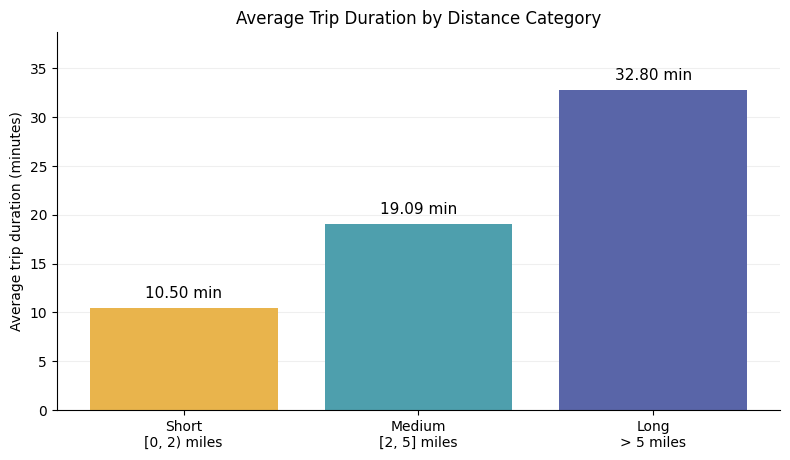

In [12]:
distance_labels = ["Short\n[0, 2) miles", "Medium\n[2, 5] miles", "Long\n> 5 miles"]
distance_colors = ["#E9B44C", "#4E9FAD", "#5965A8"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    distance_labels,
    distance_analysis["avg_trip_duration_minutes"],
    color=distance_colors,
)
ax.bar_label(
    bars,
    labels=[
        f"{value:.2f} min" for value in distance_analysis["avg_trip_duration_minutes"]
    ],
    padding=5,
    fontsize=11,
)
ax.set_title("Average Trip Duration by Distance Category")
ax.set_ylabel("Average trip duration (minutes)")
ax.margins(y=0.18)
ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(
    output_dir / "average_duration_by_distance.png", dpi=180, bbox_inches="tight"
)
plt.show()
plt.close(fig)

## Bonus: Data-quality summary

This summary reads records with `is_valid = false` from raw staging.
The percentage denominator is all raw records; `affected_revenue` is the signed sum of rejected amounts, not lost revenue.


In [13]:
data_quality = con.sql("""
    select is_valid, affected_rows, affected_rows_pct, affected_revenue,
           avg_total_amount, avg_trip_distance, max_trip_distance
    from mart_data_quality
""").df()

display(data_quality)

,is_valid,affected_rows,affected_rows_pct,affected_revenue,avg_total_amount,avg_trip_distance,max_trip_distance
0,False,15308,0.43,-438796.2,-28.66,3.55,319.31


## Close the database connection

Run this cell before rebuilding the database in another process. If notebook execution stops early, close `con` explicitly or stop the kernel.


In [14]:
con.close()